In [1]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

# Import the framework
from nowkit.nowcasting_framework import (
    NowcastConfig,
    DataManager,
    ModelManager,
    EvaluationManager,
    VisualizationManager,
    InferencePipeline
)

# Import model
from sklearn.ensemble import RandomForestRegressor

## 1. Configuration

In [2]:
# Configure Random Forest experiment
# Using 10-model ensemble to average stochastic outputs
config = NowcastConfig(
    target_variable="gdpc1",
    test_start_date="2005-03-01",
    test_end_date="2010-03-01",
    n_lags=4,
    n_ensemble_models=10,  # Average 10 models due to stochasticity
    quarterly_only=True
)

print("Random Forest Configuration:")
print("=" * 60)
for key, value in config.to_dict().items():
    print(f"{key:20s}: {value}")
print("=" * 60)

Random Forest Configuration:
target              : gdpc1
test_period         : 2005-03-01 to 2010-03-01
lags                : [-2, -1, 0, 1, 2]
n_lags              : 4
n_ensemble          : 10


## 2. Data Loading

In [3]:
# Initialize and load data
data_manager = DataManager(config)
data_manager.load_data().prepare_test_data()

# Display data summary
data_manager.summary()

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods


,Metric,Value
0,Total Observations,913
1,Test Periods,21
2,Variables,24
3,Target Variable,gdpc1
4,Missing in Target (%),66.9%


## 3. Model Training and Backtesting

In [4]:
# Configure Random Forest parameters
rf_params = {
    'n_estimators': 100,
    'criterion': 'squared_error',
    'max_depth': None,
    'min_samples_split': 0.01,
    'min_samples_leaf': 0.01,
    'max_features': 'sqrt',
    'bootstrap': False,
    'random_state': 42
}

# Create model manager and run backtest
rf_model = ModelManager(RandomForestRegressor, rf_params, config)
rf_model.run_backtest(data_manager)


Running backtest with 10 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed
✓ Backtest complete: 21 periods processed


## 4. Evaluation

In [5]:
# Evaluate model performance
evaluator = EvaluationManager()
evaluator.add_model_results(
    'Random Forest (10-ensemble)',
    rf_model.get_predictions(),
    data_manager.actuals,
    config.lags
)

# Display performance metrics
print("\nPERFORMANCE BY VINTAGE:")
print("-" * 60)
display(evaluator.get_performance_table().round(6))

print("\n" + evaluator.summary_report())


PERFORMANCE BY VINTAGE:
------------------------------------------------------------


Model,Vintage,Random Forest (10-ensemble)
0,-2,0.008604
1,-1,0.008408
2,0,0.006809
3,1,0.004954
4,2,0.004378



MODEL EVALUATION SUMMARY

Model: Random Forest (10-ensemble)
  Average RMSE across vintages: 0.006631
  Best vintage: lag=2 (RMSE=0.004378)



## 5. Visualization

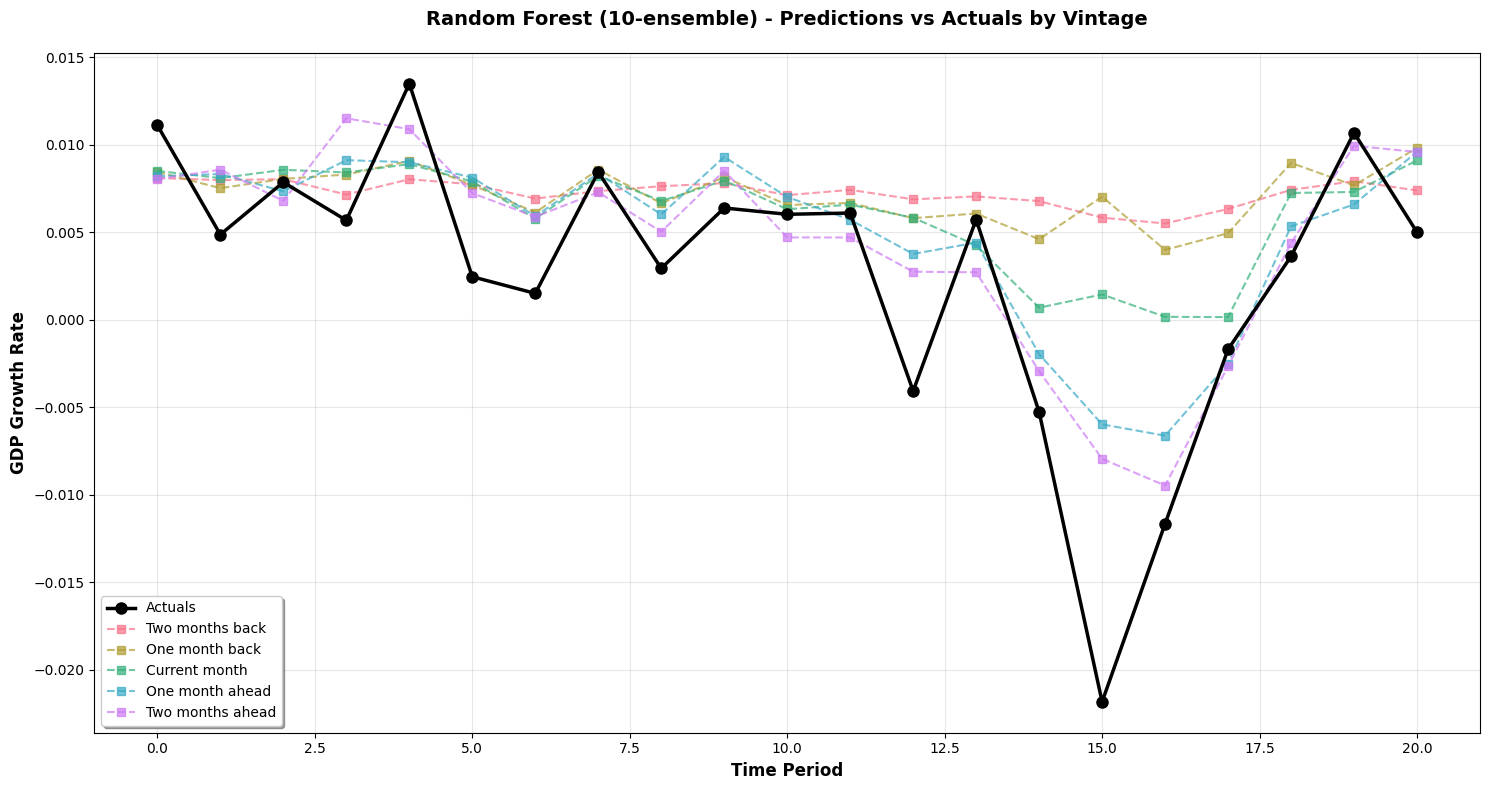

In [6]:
# Create visualization manager
viz = VisualizationManager(evaluator)

# Plot predictions vs actuals
fig1 = viz.plot_predictions_vs_actuals('Random Forest (10-ensemble)')
plt.show()

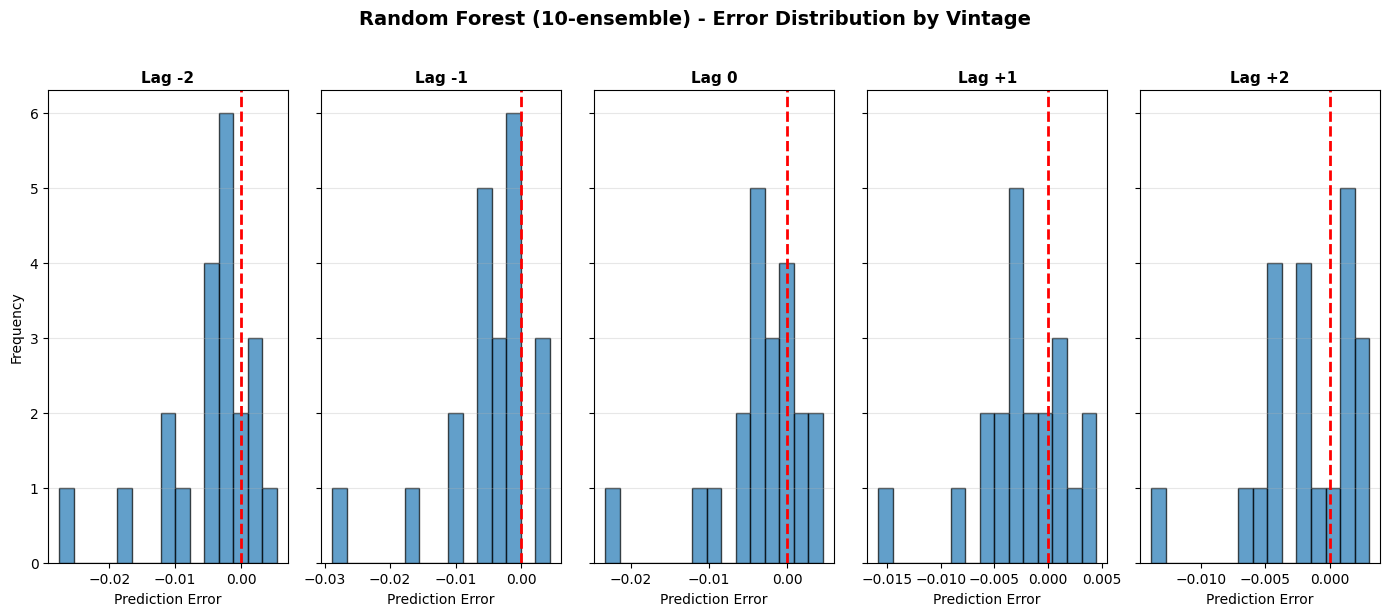

In [7]:
# Plot error distribution
fig2 = viz.plot_error_distribution('Random Forest (10-ensemble)')
plt.show()

## 6. Production Inference

In [8]:
# Create inference pipeline
inference = InferencePipeline(rf_model, data_manager, config)

# Predict future quarter
prediction = inference.predict_new_date("2010-06-01")

print("\nFUTURE PREDICTION:")
print("=" * 60)
for key, value in prediction.items():
    print(f"{key:20s}: {value}")


FUTURE PREDICTION:
target_date         : 2010-06-01
prediction          : 0.007410620871730821
target_variable     : gdpc1
n_models            : 10
model_class         : RandomForestRegressor


## Summary

This notebook implements Random Forest regression for GDP nowcasting. Random Forests build multiple decision trees with different random subsets of features and training data. We further average across 10 trained models to reduce variance in the predictions.

The model is configured with 100 trees, using the square root of features at each split and no bootstrapping. These settings have been tuned for the nowcasting task, but could be adjusted based on specific requirements or data characteristics.